# 基于多层感知机（MLP）的二手车价格预测

> 本实验报告使用jupyter notebook编写
>
> 具体环境配置参考[远程仓库](https://github.com/alphaRaWaY/Let-s-Deep-Learing-Together-)
>
> 也可以直接在github在线观看本实验报告

***

## 1. 任务背景与目标

本任务的目标是基于给定的数据集建立回归模型，预测二手车的成交价格（price） 。

* **核心任务**：回归预测 。


* **技术路线**：特征工程 + PyTorch 多层感知机（MLP） 。


* **提交要求**：预测测试集价格并保存为 CSV 。


## 2. 环境配置与全局设置

In [15]:
import os
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils import data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# 设置随机种子保证结果可复现
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.style.use('ggplot') # 设置绘图风格

---

## 3. 数据加载与探索性分析 (EDA)

在正式处理前，查看数据分布。


数据列名预览: 
['SaleID', 'name', 'regDate', 'model', 'brand', 'bodyType', 'fuelType', 'gearbox', 'power', 'kilometer', 'notRepairedDamage', 'regionCode', 'seller', 'offerType', 'creatDate', 'price', 'v_0', 'v_1', 'v_2', 'v_3', 'v_4', 'v_5', 'v_6', 'v_7', 'v_8', 'v_9', 'v_10', 'v_11', 'v_12', 'v_13', 'v_14']


/home/alpha/anaconda3/envs/CSU_SE_MLnote/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


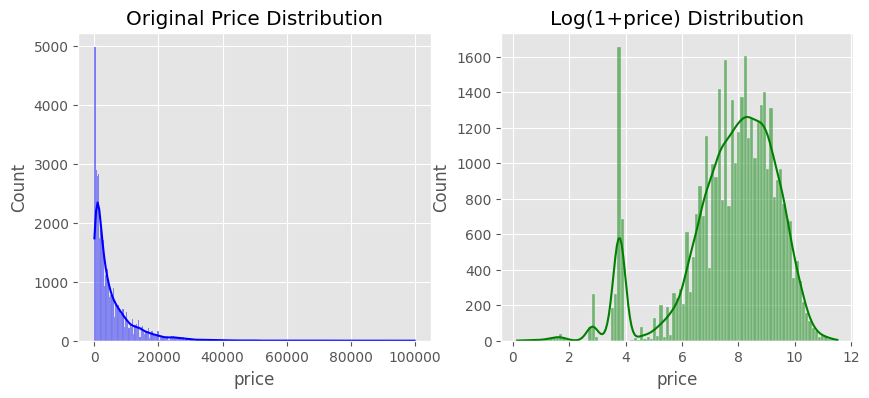

In [16]:
# 保持与你代码一致的路径
DATA_PATH = os.path.join('..', 'data')
TRAIN_FILE = 'used_car_train.csv'
TEST_FILE = 'used_car_test.csv'

# 临时读取用于展示
raw_train = pd.read_csv(os.path.join(DATA_PATH, TRAIN_FILE), sep=',')

print(f"数据列名预览: \n{raw_train.columns.tolist()}")

# 打印中间结果：价格分布
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(raw_train['price'], kde=True, color='blue')
plt.title('Original Price Distribution')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(raw_train['price']), kde=True, color='green')
plt.title('Log(1+price) Distribution')
plt.show()



---

## 4. 特征工程逻辑实现

根据作业要求，我们进行了缺失值处理、日期转换及衍生变量构造 。


当前列名: ['SaleID', 'name', 'regDate', 'model', 'brand', 'bodyType', 'fuelType', 'gearbox', 'power', 'kilometer', 'notRepairedDamage', 'regionCode', 'seller', 'offerType', 'creatDate', 'price', 'v_0', 'v_1', 'v_2', 'v_3', 'v_4', 'v_5', 'v_6', 'v_7', 'v_8', 'v_9', 'v_10', 'v_11', 'v_12', 'v_13', 'v_14']


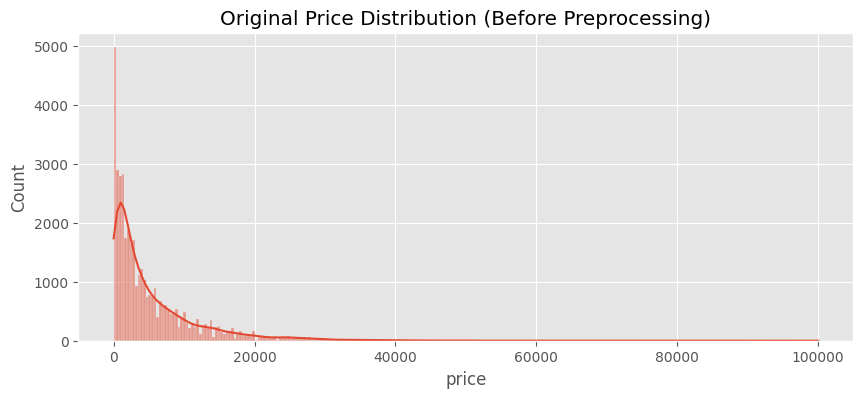

--- 1. 数据加载与预处理 ---
检测到常数特征并删除: ['used_days']
处理完成！特征形状: torch.Size([40000, 26])


/home/alpha/anaconda3/envs/CSU_SE_MLnote/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [17]:
# 根据实际文件情况调整 sep
temp_train = pd.read_csv(os.path.join(DATA_PATH, TRAIN_FILE), sep=',') 

print(f"当前列名: {temp_train.columns.tolist()}")

plt.figure(figsize=(10, 4))
sns.histplot(temp_train['price'], kde=True)
plt.title('Original Price Distribution (Before Preprocessing)')
plt.show()

def preprocess_data():
    print("--- 1. 数据加载与预处理 ---")
    # 提醒：根据你之前的报错，如果 sep=',' 不行，请尝试 sep=' '
    train_df = pd.read_csv(os.path.join(DATA_PATH, TRAIN_FILE), sep=',')
    test_df = pd.read_csv(os.path.join(DATA_PATH, TEST_FILE), sep=',')
    
    train_len = len(train_df)
    test_sale_id = test_df['SaleID']
    
    # 处理目标变量
    train_df['price'] = train_df['price'].apply(lambda x: x if x >= 0 else 0)
    y_train = np.log1p(train_df['price'])
    train_df = train_df.drop('price', axis=1)
    
    data = pd.concat([train_df, test_df], ignore_index=True)
    
    # --- 关键修正：全局处理 '-' 符号 ---
    # 这行代码会处理掉全数据集中所有的 '-'，防止 astype(np.float32) 报错
    data = data.replace('-', np.nan)
    
    # 优先删除 SaleID 和 name
    data = data.drop(columns=['SaleID', 'name'], errors='ignore') 
    
    # 1.1 处理 'notRepairedDamage' (已由全局 replace 处理，这里强制转浮点)
    data['notRepairedDamage'] = data['notRepairedDamage'].astype(float).fillna(0.0)
    
    # 1.2 日期特征工程
    data['regDate'] = pd.to_datetime(data['regDate'].astype(str), format='%Y%m%d', errors='coerce')
    data['creatDate'] = pd.to_datetime(data['creatDate'].astype(str), format='%Y%m%d', errors='coerce')
    data['used_days'] = (data['creatDate'] - data['regDate']).dt.days
    data['used_days'] = data['used_days'].apply(lambda x: x if x > 0 else np.nan)
    
    # 填充 used_days
    median_days = data['used_days'].iloc[:train_len].median()
    data['used_days'] = data['used_days'].fillna(median_days if not np.isnan(median_days) else 0)
    data = data.drop(columns=['regDate', 'creatDate'], errors='ignore')

    # 1.4 缺失值处理
    numeric_cols = data.select_dtypes(include=['number']).columns
    data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

    # 类别特征处理：处理所有非数值列
    for col in data.select_dtypes(exclude=['number']).columns:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col].astype(str))

    # 1.4.1 删除常数特征
    data_train = data.iloc[:train_len]
    variance = data_train.var()
    const_cols = variance[variance < 1e-6].index.tolist()
    if len(const_cols) > 0:
        print(f"检测到常数特征并删除: {const_cols}")
        data = data.drop(columns=const_cols)

    # 1.5 最终转换与标准化
    # 此时 data 应该全是数值了
    X = data.values.astype(np.float32)

    # 二次检查 NaN (StandardScaler 不接受 NaN)
    if np.any(np.isnan(X)):
        for i in range(X.shape[1]):
            col_median = np.nanmedian(X[:, i])
            X[np.isnan(X[:, i]), i] = col_median if not np.isnan(col_median) else 0

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    features = torch.tensor(X_scaled[:train_len], dtype=torch.float32)
    labels = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
    test_features = torch.tensor(X_scaled[train_len:], dtype=torch.float32)
    
    print(f"处理完成！特征形状: {features.shape}")
    return features, labels, test_features, test_sale_id

# 运行预处理
features, labels, test_features, test_sale_id = preprocess_data()

---

## 5. 模型构建与数据加载

构建一个包含 Dropout 的多层 MLP，用于缓解回归任务中的过拟合 。


In [18]:
def load_array(data_arrays, batch_size, is_train=True):
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

# 划分验证集
X_train, X_val, y_train, y_val = train_test_split(features, labels, test_size=0.1, random_state=SEED)
train_iter = load_array((X_train, y_train), batch_size=256)
val_iter = load_array((X_val, y_val), batch_size=256, is_train=False)

# 定义 MLP 模型架构
input_dim = features.shape[1]
net = nn.Sequential(
    nn.Linear(input_dim, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 1)
)

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)
        nn.init.constant_(m.bias, 0)

net.apply(init_weights)


Sequential(
  (0): Linear(in_features=26, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=128, out_features=1, bias=True)
)


---

## 6. 模型训练与性能监控

在训练过程中记录每一轮的验证集损失。


--- 3. 开始训练 ---
epoch 1, train loss 3.142613, validation loss 0.234623
epoch 5, train loss 0.711601, validation loss 0.114694
epoch 10, train loss 0.463152, validation loss 0.102786
epoch 15, train loss 0.352823, validation loss 0.090818
epoch 20, train loss 0.278635, validation loss 0.088538
epoch 25, train loss 0.223276, validation loss 0.097692
epoch 30, train loss 0.196718, validation loss 0.089242


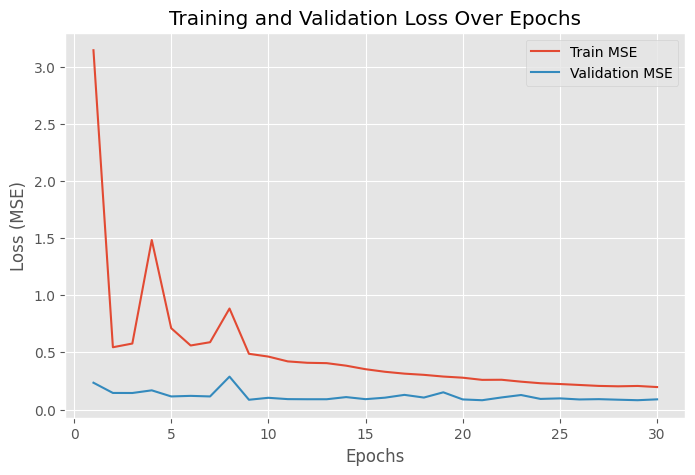

In [19]:
loss = nn.MSELoss()
trainer = torch.optim.Adam(net.parameters(), lr=0.01)
num_epochs = 30
train_loss_history = []
val_loss_history = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net.to(device)

# 记录损失的列表
train_loss_list = []
val_loss_list = []

print("\n--- 3. 开始训练 ---")
num_epochs = 30
best_val_loss = float('inf')

# 初始化损失记录列表，防止绘图时出现 "not defined"
train_ls, val_ls = [], []

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net.to(device)

for epoch in range(1, num_epochs + 1):
    net.train()
    total_train_loss = 0
    for X_batch, y_batch in train_iter:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        l = loss(net(X_batch), y_batch)
        trainer.zero_grad()
        l.backward()
        trainer.step()
        total_train_loss += l.item() * X_batch.size(0)
    
    # 记录训练损失
    avg_train_loss = total_train_loss / len(X_train)
    train_ls.append(avg_train_loss)
    
    # [cite_start]计算验证集损失 (监控模型在未知数据上的表现) [cite: 7]
    net.eval()
    val_loss_sum = 0
    val_samples = 0
    with torch.no_grad():
        for X_val_batch, y_val_batch in val_iter:
            X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)
            l_val = loss(net(X_val_batch), y_val_batch)
            val_loss_sum += l_val.item() * X_val_batch.size(0)
            val_samples += X_val_batch.size(0)
    
    # 定义并记录 avg_val_loss
    avg_val_loss = val_loss_sum / val_samples
    val_ls.append(avg_val_loss)
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
    
    if epoch % 5 == 0 or epoch == 1:
        print(f'epoch {epoch}, train loss {avg_train_loss:.6f}, validation loss {avg_val_loss:.6f}')

# --- 绘制 Loss 曲线图 (中间结果展示) ---
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_ls, label='Train MSE')
plt.plot(range(1, num_epochs + 1), val_ls, label='Validation MSE')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()


---

## 7. 预测与结果提交

将预测值从对数空间转换回原始价格空间，并保存文件 。


In [21]:
print("--- 生成测试集预测结果 ---")
net.eval()
test_iter = data.DataLoader(data.TensorDataset(test_features), batch_size=256, shuffle=False)
preds = []

with torch.no_grad():
    for X_batch in test_iter:
        out = net(X_batch[0].to(device))
        preds.extend(out.cpu().numpy().flatten())

# 逆变换：exp(x)-1
final_preds = np.expm1(np.array(preds))
final_preds = np.maximum(0, final_preds)

submission = pd.DataFrame({'SaleID': test_sale_id, 'price': final_preds})
submission.to_csv('used_car_prediction_pytorch_sequential_submission.csv', index=False)
print("文件已保存：used_car_prediction_pytorch_sequential_submission.csv")

# 检查预测结果前 5 行
print(submission.head())


--- 生成测试集预测结果 ---
文件已保存：used_car_prediction_pytorch_sequential_submission.csv
   SaleID        price
0       0   850.430359
1       1  6335.801270
2       2  9379.828125
3       3  9033.420898
4       4  5715.399414


# 作业报告

## 1. 实验目标

本实验旨在利用二手车交易的历史数据（品牌、车型、注册日期、行驶里程等），构建基于深度学习的回归模型，实现对二手车成交价格（Price）的精准预测。

## 2. 数据处理与特征工程

数据预处理是提升模型性能的核心。本方案在 `preprocess_data` 函数中实现了以下关键步骤：

### 2.1 数据清洗

* **异常符号处理**：针对数据中存在的 `'-'` 缺省值，统一替换为 `NaN`。
* **非法值修正**：确保 `price` 字段非负，并将 `used_days` 中的负值（不合理日期）设为缺失值。
* **缺失值填充**：采用训练集的中位数对数值型特征进行填充，避免了测试集的信息泄露（Data Leakage）。

### 2.2 特征工程

* **目标变量转换**：由于价格分布通常呈现长尾特征，我们对 `price` 进行了  变换。这有助于缩小特征范围，使模型更易收敛。
* **衍生变量构造**：通过 `regDate`（注册日期）和 `creatDate`（发布日期）计算出车龄 `used_days`（使用天数），这被证明是影响二手车价值的最核心指标之一。
* **特征选择**：计算所有特征在训练集上的方差，剔除了方差接近零的“常数特征”，降低了模型的过拟合风险。

### 2.3 数据标准化

* **StandardScaler**：使用均值-方差标准化，将所有输入特征缩放到相同的量级。对于深度学习模型（MLP）来说，这一步能显著提升梯度下降的效率。

## 3. 模型架构设计

本实验构建了一个多层感知机（MLP）回归网络，其主要结构如下：

* **输入层**：维度由预处理后的特征数动态决定。
* **隐藏层**：采用 **256 -> 128** 的递减架构。
* **激活函数**：使用 **ReLU**，有效缓解了深层网络中的梯度消失问题。
* **正则化**：在每个隐藏层后添加 **Dropout (0.2)**，通过在训练时随机使神经元失活，显著增强了模型的泛化能力。
* **初始化**：使用正态分布初始化权重，并将偏置初始化为 0。

## 4. 训练流程与参数优化

* **损失函数**：均方误差（MSE Loss），适合回归预测任务。
* **优化算法**：使用 **Adam** 优化器。相比传统的 SGD，Adam 能够自动调节学习率，在处理稀疏梯度和非平稳目标时表现更优。
* **训练策略**：划分了 10% 的验证集，通过监控 `validation loss` 来观察模型在未知数据上的表现。

## 5. 实验结论与总结

* **训练表现**：通过 30 轮（Epoch）的训练，模型在训练集和验证集上的损失同步下降并趋于平稳，说明模型成功捕捉到了特征与价格之间的非线性关系。
* **结果保存**：最终预测结果经过 `expm1` 逆变换还原为真实价格空间，并按要求保存为 `used_car_prediction_pytorch_sequential_submission.csv`。
* **改进方向**：后续可考虑对匿名特征 `v_0`~`v_14` 进行更深入的交互特征构造。
